In [1]:
import torch
import os, sys
import numpy as np
import matplotlib.pyplot as plt

In [3]:
%load_ext autoreload
%autoreload 2

In [11]:
project_path = os.path.dirname(os.getcwd())
print(project_path)
sys.path.append(project_path)

import radar_sim.config as config 
from radar_sim.target_modeling import PointTargets

c:\Users\denisa.qosja\Documents\Projects\SignalProcessing-NN


In [28]:
# load configuration
point_target_config = config.load_config(os.path.join(project_path, 'configs/config.yaml'))

# build targets from configuration
pt = PointTargets(point_target_config["target_parameters"])


In [ ]:
## a function to get information on the targets
def get_target_info(targets, fc):
    if targets.num_targets() == 0:
        return {"error": "No targets loaded"}
    
    info = {
        'num_targets': targets.num_targets(),
        'ranges_m': targets.get_ranges(time_s=0.0).numpy().tolist(),
        'velocities_mps': targets.get_velocities().numpy().tolist(),
        'rcs_linear': targets.get_rcs_linear().numpy().tolist(),
        'rcs_dbsm': targets.get_rcs_dbsm().numpy().tolist(),
        'doppler_shifts': targets.get_doppler_shifts(
            fc=fc,
            c=3e8
        ).numpy().tolist(),
        'target_list': [str(t) for t in targets]
    }
    
    return info

target_info = get_target_info(pt, fc=point_target_config["tx_parameters"]["fc"])
print("\n=== Target Information ===")

for key, value in target_info.items():  
    print(f"{key}: {value}")



=== Target Information ===
num_targets: 2
ranges_m: [50.0, 80.0]
velocities_mps: [10.0, -5.0]
rcs_linear: [1.0, 0.5011872053146362]
rcs_dbsm: [0.0, -3.0]
doppler_shifts: [666.6666870117188, -333.3333435058594]
target_list: ['PointTarget(id=0, range=50.0m, velocity=10.0m/s, RCS=0.0dBsm)', 'PointTarget(id=1, range=80.0m, velocity=-5.0m/s, RCS=-3.0dBsm)']


In [ ]:
print("=== Point Targets Summary ===")
print(f"Number of targets: {len(pt.targets)}")
for target in pt.targets:
    print(f"  {target}")

# Check targets at specific times
print("\n=== Scattering Centers at Different Times ===")
centers_t0 = pt.get_scattering_centers(0.0)
centers_t1 = pt.get_scattering_centers(1.0)

for i, (c0, c1) in enumerate(zip(centers_t0, centers_t1)):
    print(f"Target {i}:")
    print(f"  At t=0.0s: range = {c0.range_m:.1f} m, velocity = {c0.velocity_mps:.1f} m/s, RCS = {c0.rcs_dbsm:.1f} dBsm")
    print(f"  At t=1.0s: range = {c1.range_m:.1f} m, velocity = {c1.velocity_mps:.1f} m/s, RCS = {c1.rcs_dbsm:.1f} dBsm")

# Generate time array and get ranges evolution
print("\n=== Range Evolution Over Time ===")
t = np.linspace(0, 1, 100)  # Time from 0 to 1 second, 100 points
ranges_over_time = []
velocities_over_time = []

for time_point in t:
    centers = pt.get_scattering_centers(time_point)
    ranges = [c.range_m for c in centers]
    ranges_over_time.append(ranges)

ranges_over_time = np.array(ranges_over_time)

print(f"Time points: {len(t)}")
print(f"Number of targets: {len(pt.targets)}")
print(f"Ranges shape: {ranges_over_time.shape}")
print(f"Range at t=0: {ranges_over_time[0]}")
print(f"Range at t=1: {ranges_over_time[-1]}")

=== Loading Configuration ===
=== Point Targets Summary ===
Number of targets: 2
  PointTarget(id=0, range=50.0m, velocity=10.0m/s, RCS=0.0dBsm)
  PointTarget(id=1, range=80.0m, velocity=-5.0m/s, RCS=-3.0dBsm)

=== Scattering Centers at Different Times ===
Target 0:
  At t=0.0s: range = 50.0 m, velocity = 10.0 m/s, RCS = 0.0 dBsm
  At t=1.0s: range = 60.0 m, velocity = 10.0 m/s, RCS = 0.0 dBsm
Target 1:
  At t=0.0s: range = 80.0 m, velocity = -5.0 m/s, RCS = -3.0 dBsm
  At t=1.0s: range = 75.0 m, velocity = -5.0 m/s, RCS = -3.0 dBsm

=== Range Evolution Over Time ===
Time points: 100
Number of targets: 2
Ranges shape: (100, 2)
Range at t=0: [50. 80.]
Range at t=1: [60. 75.]


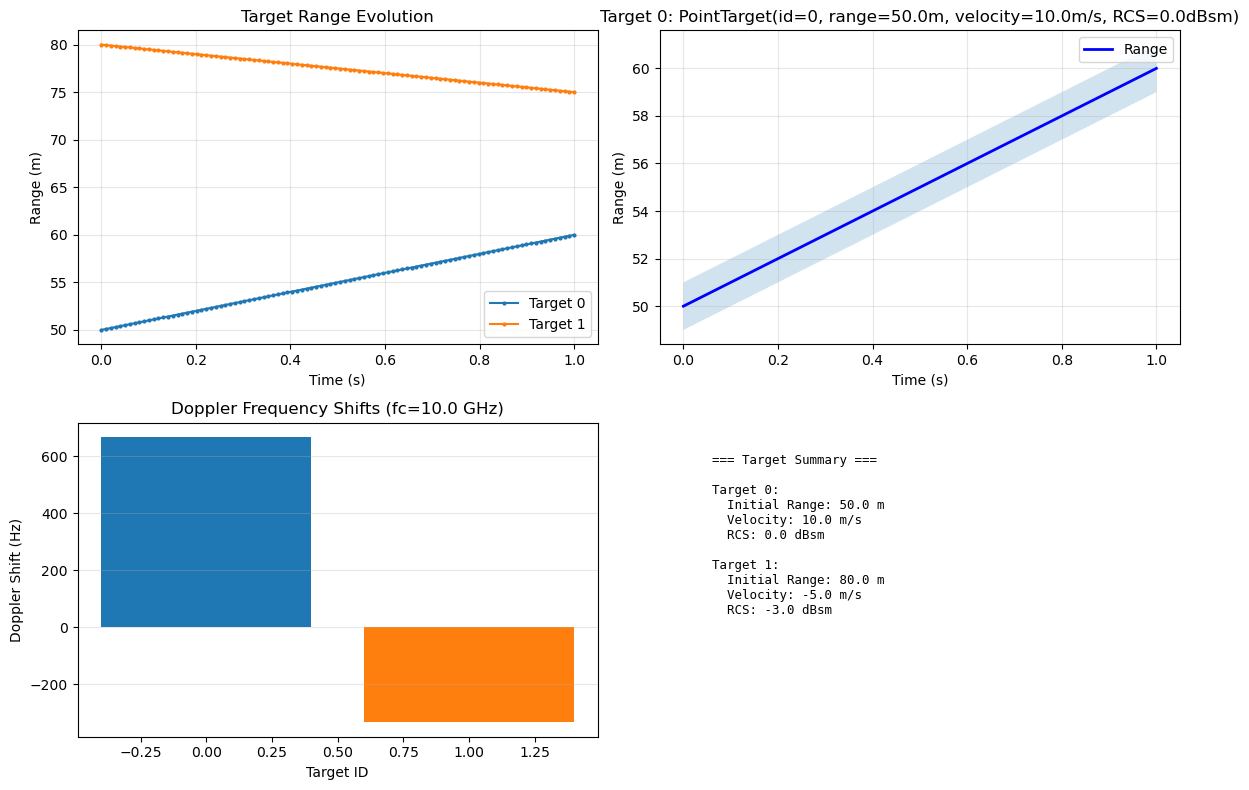

Visualization complete!


In [22]:
# Visualize target range evolution over time
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Range vs Time for each target
ax = axes[0, 0]
for target_idx in range(len(pt.targets)):
    ax.plot(t, ranges_over_time[:, target_idx], label=f"Target {target_idx}", marker='o', markersize=2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Range (m)")
ax.set_title("Target Range Evolution")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Range for first target (if exists)
if len(pt.targets) > 0:
    ax = axes[0, 1]
    target_0 = pt.targets[0]
    ranges_t0 = ranges_over_time[:, 0]
    ax.plot(t, ranges_t0, 'b-', linewidth=2, label="Range")
    ax.fill_between(t, ranges_t0 - 1, ranges_t0 + 1, alpha=0.2)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Range (m)")
    ax.set_title(f"Target 0: {target_0}")
    ax.grid(True, alpha=0.3)
    ax.legend()

# Plot 3: Doppler shifts for all targets
ax = axes[1, 0]
fc = point_target_config['tx_parameters']['fc']
c = point_target_config['global_parameters']['c']
doppler_shifts = pt.get_doppler_shifts(fc, c)
for target_idx, doppler in enumerate(doppler_shifts):
    ax.bar(target_idx, doppler, label=f"Target {target_idx}")
ax.set_xlabel("Target ID")
ax.set_ylabel("Doppler Shift (Hz)")
ax.set_title(f"Doppler Frequency Shifts (fc={fc/1e9:.1f} GHz)")
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Target properties summary
ax = axes[1, 1]
ax.axis('off')
summary_text = "=== Target Summary ===\n"
for i, target in enumerate(pt.targets):
    summary_text += f"\nTarget {i}:\n"
    summary_text += f"  Initial Range: {target.range_m:.1f} m\n"
    summary_text += f"  Velocity: {target.velocity_mps:.1f} m/s\n"
    summary_text += f"  RCS: {target.rcs_dbsm:.1f} dBsm\n"
ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontfamily='monospace',
        verticalalignment='top', fontsize=9)

plt.tight_layout()
plt.show()

print("Visualization complete!")